In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [5]:
!unzip -qq "/content/drive/MyDrive/DEEP LEARNING/chip_data.zip" -d data

In [6]:
# Load dataset from a folder (structured as: dataset/class_name/images)
dataset_path = "./data/dataset/"
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=transform)

In [7]:
# Display some input images
def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(5, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0)  # Convert tensor format (C, H, W) to (H, W, C)
        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")
    plt.show()

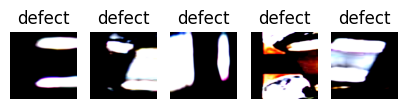

In [8]:
# Show sample images from the training dataset
show_sample_images(train_dataset)

In [9]:
# Get the total number of samples in the training dataset
print(f"Total number of training samples: {len(train_dataset)}")

# Get the shape of the first image in the dataset
first_image, label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")

Total number of training samples: 172
Shape of the first image: torch.Size([3, 224, 224])


In [10]:
# Get the total number of samples in the testing dataset
print(f"Total number of test samples: {len(test_dataset)}")

# Get the shape of the first image in the dataset
first_image1,label =test_dataset[0]
print(f"Shape of the first image: {first_image1.shape}")


Total number of test samples: 121
Shape of the first image: torch.Size([3, 224, 224])


In [11]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [12]:
## Step 2: Load Pretrained Model and Modify for Transfer Learning
# Load a pre-trained VGG19 model
# write your code here
from torchvision.models import VGG19_Weights
model=models.vgg19(weights=VGG19_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 184MB/s]


In [13]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [14]:
from torchsummary import summary
# Print model summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [15]:
# Modify the final fully connected layer to match the dataset classes
# Write your code here
model.classifier[-1]=nn.Linear(model.classifier[-1].in_features,1)

In [16]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [17]:
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [18]:
# Freeze all layers except the final layer
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature extractor layers

In [19]:
# Include the Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [20]:
## Step 3: Train the Model
def train_model(model, train_loader,test_loader,num_epochs=10):
    train_losses=[]
    val_losses=[]
    model.train()
    for epoch in range(num_epochs):
      running_loss=0.0
      for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels.unsqueeze(1).float())
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
      train_losses.append(running_loss/len(train_loader))

      model.eval()
      val_loss=0.0
      with torch.no_grad():
        for images,labels in test_loader:
          images,labels=images.to(device),labels.to(device)
          outputs=model(images)
          loss=criterion(outputs,labels.unsqueeze(1).float())
          val_loss+=loss.item()
      val_losses.append(val_loss/len(test_loader))
      model.train()
      print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')

    # Plot training and validation loss
    print("Name: NITHYA D")
    print("Register Number: 212223240110")
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

In [21]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [22]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Epoch [1/10], Train Loss: 0.4958, Validation Loss: 0.2573
Epoch [2/10], Train Loss: 0.1632, Validation Loss: 0.1324
Epoch [3/10], Train Loss: 0.0466, Validation Loss: 0.2329
Epoch [4/10], Train Loss: 0.0141, Validation Loss: 0.2862
Epoch [5/10], Train Loss: 0.0021, Validation Loss: 0.1906
Epoch [6/10], Train Loss: 0.0008, Validation Loss: 0.1516
Epoch [7/10], Train Loss: 0.0004, Validation Loss: 0.1450
Epoch [8/10], Train Loss: 0.0003, Validation Loss: 0.1539
Epoch [9/10], Train Loss: 0.0001, Validation Loss: 0.1688
Epoch [10/10], Train Loss: 0.0001, Validation Loss: 0.1867
Name: NITHYA D
Register Number: 212223240110


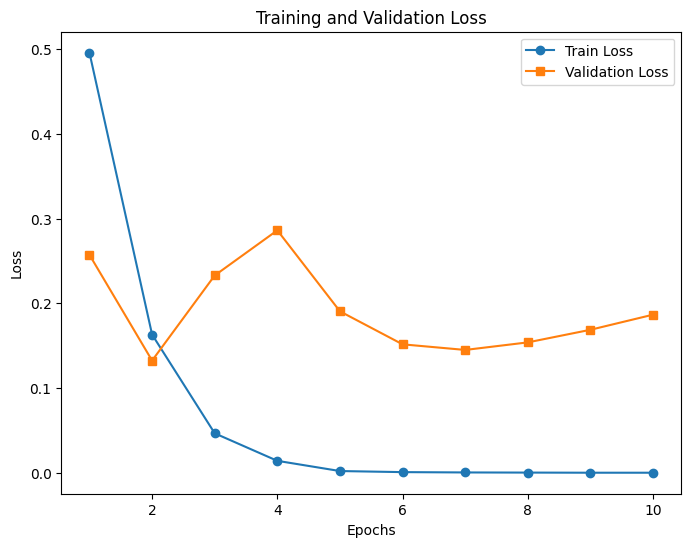

In [23]:
# Train the model
# Write your code here
train_model(model,train_loader,test_loader)

In [25]:
def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int().squeeze()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    cm = confusion_matrix(all_labels, all_preds)
    print("Name: NITHYA D")
    print("Register Number: 212223240110")
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    print("Name: NITHYA D")
    print("Register Number: 212223240110")
    print("Classification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=train_dataset.classes
        )
    )

Test Accuracy: 0.9421
Name: NITHYA D
Register Number: 212223240110


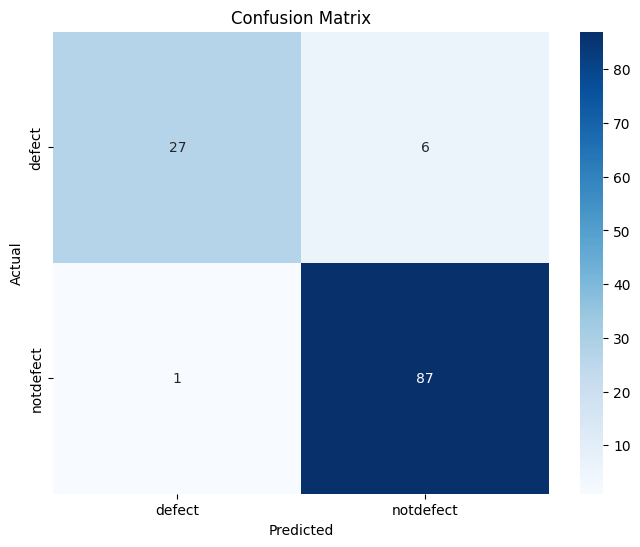

Name: NITHYA D
Register Number: 212223240110
Classification Report:
              precision    recall  f1-score   support

      defect       0.96      0.82      0.89        33
   notdefect       0.94      0.99      0.96        88

    accuracy                           0.94       121
   macro avg       0.95      0.90      0.92       121
weighted avg       0.94      0.94      0.94       121



In [26]:
# Evaluate the model
test_model(model,test_loader)

In [29]:
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    with torch.no_grad():
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        prob = torch.sigmoid(output)
        predicted = (prob > 0.5).int().squeeze().item()
    class_names = dataset.classes
    image = image.cpu().numpy().transpose((1, 2, 0))
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)
    image_to_display = image
    plt.figure(figsize=(4, 4))
    plt.imshow(image_to_display)
    plt.title(
        f'Actual: {class_names[label]}\nPredicted: {class_names[predicted]}'
    )
    plt.axis("off")
    plt.show()
    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted]}')

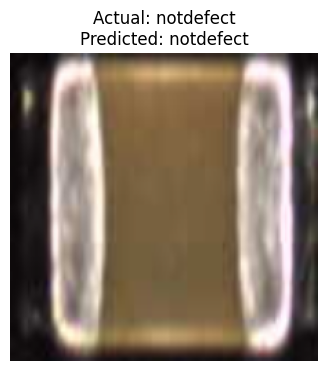

Actual: notdefect, Predicted: notdefect


In [30]:
# Example Prediction
predict_image(model, image_index=55, dataset=test_dataset)


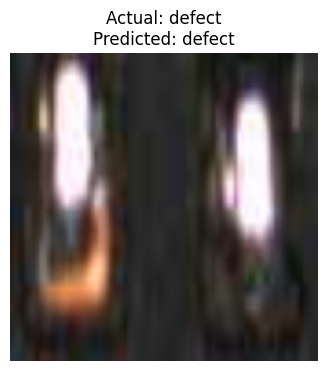

Actual: defect, Predicted: defect


In [31]:
#Example Prediction
predict_image(model, image_index=25, dataset=test_dataset)